In [1]:
import pandas as pd
import numpy as np
#The dataset doesn't come with columns already labeled, so we have to do it manually.
#Load feature names from the kddcup.names into a list.
feature_column_names = [] #This list will hold the feature names for each column.
with open("kddcup.names") as file: 
    file.readline() #No feature names on the first line, so skip it.
    for line in file: 
        line = line.split(':',1)[0]
        feature_column_names.append(line)
feature_column_names.append('label') #Adding the label column because that final column consists of either normal. or an attack name.

In [2]:
#Load our dataset, the 10% subset
df = pd.read_csv("kddcup.data_10_percent.gz", header=None) 
df.columns = feature_column_names #Assign each column with our feature name
y = df['label'] #Will be used for evaluation, but now it isn't needed.

#Creating binary labels(0 if normal., else 1)
binary_labels = np.where(y == 'normal.', 0, 1)
df = df.drop('label',axis=1) #We don't need this label column right now, so dropping it.
pd.set_option('display.max_columns', None)


In [3]:
#Begin Cleaning data
#Observing the data and seeing what the data types are.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 41 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocol_type                494021 non-null  object 
 2   service                      494021 non-null  object 
 3   flag                         494021 non-null  object 
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                    494021 non-null  int64  
 12  num_compromised              494021 non-null  int64  
 13 

In [4]:

#1. Handling Missing Values
df = df.dropna() #Drop all rows with at least one missing value

In [5]:
#Observe dropping did nothing as all data points have a value for their features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 41 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   duration                     494021 non-null  int64  
 1   protocol_type                494021 non-null  object 
 2   service                      494021 non-null  object 
 3   flag                         494021 non-null  object 
 4   src_bytes                    494021 non-null  int64  
 5   dst_bytes                    494021 non-null  int64  
 6   land                         494021 non-null  int64  
 7   wrong_fragment               494021 non-null  int64  
 8   urgent                       494021 non-null  int64  
 9   hot                          494021 non-null  int64  
 10  num_failed_logins            494021 non-null  int64  
 11  logged_in                    494021 non-null  int64  
 12  num_compromised              494021 non-null  int64  
 13 

In [6]:
import sklearn
from sklearn.preprocessing import OneHotEncoder
#2. Categorical Encoding, in my case will use One Hot Encoding for all features that are symbolic
categorial_columns = ['protocol_type','service','flag','land','logged_in','is_host_login','is_guest_login']
one_hot_encoder = OneHotEncoder(sparse_output = False)
encoder = one_hot_encoder.fit_transform(df[categorial_columns])
one_hot_encoded_df = pd.DataFrame(encoder, columns = one_hot_encoder.get_feature_names_out(categorial_columns))

In [7]:
one_hot_encoded_df.info() #All symbolic features have now been encoded

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494021 entries, 0 to 494020
Data columns (total 87 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   protocol_type_icmp   494021 non-null  float64
 1   protocol_type_tcp    494021 non-null  float64
 2   protocol_type_udp    494021 non-null  float64
 3   service_IRC          494021 non-null  float64
 4   service_X11          494021 non-null  float64
 5   service_Z39_50       494021 non-null  float64
 6   service_auth         494021 non-null  float64
 7   service_bgp          494021 non-null  float64
 8   service_courier      494021 non-null  float64
 9   service_csnet_ns     494021 non-null  float64
 10  service_ctf          494021 non-null  float64
 11  service_daytime      494021 non-null  float64
 12  service_discard      494021 non-null  float64
 13  service_domain       494021 non-null  float64
 14  service_domain_u     494021 non-null  float64
 15  service_echo     

In [8]:
#3. Standardizing Numeric Features
from sklearn.preprocessing import StandardScaler
#Just want to standardize the numeric feature as categorical are already standardized
numerical_df = df.drop(categorial_columns, axis = 1)
scaler = StandardScaler()
standardized_numerical = scaler.fit_transform(numerical_df)
standardized_numerical_df = pd.DataFrame(data = standardized_numerical, columns = numerical_df.columns)
#Recombine the numeric and categorical columns
preprocessed_df = pd.concat([standardized_numerical_df, one_hot_encoded_df], axis=1)


In [9]:
# #4 Dataset will now be split into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.svm import OneClassSVM
from sklearn.metrics import f1_score

#Create normal and anomaly data
anomaly_indices = np.where(binary_labels == 1)[0]
anomaly_data = preprocessed_df.iloc[anomaly_indices]

normal_indices = np.where(binary_labels == 0)[0]
normal_data = preprocessed_df.iloc[normal_indices]
#As mentioned in the report, we will do a 80-20 split for training and testing
normal_train, normal_test = train_test_split(normal_data, test_size = 0.2, random_state = 42)

#Use a length of normal_test here because of computational costs and to be fair to both classes
anomaly_test = anomaly_data.sample(n=len(normal_test), random_state=42) 
nu_potential = [0.01, 0.05, 0.1] #Will use these nu values for testing
gamma_potential = ['scale',0.1, 0.01] #Will use these gamma values for testing
best_f1 = -1
best_model = None
best_params = {}
#Selecting the best hyperparameters here
#Decided to keep rbf as kernel because we are dealing with non-linearity
#Just wanted to select the best set of hyperparameter, essentially choose the one with the best F1 score.
for nu in nu_potential:
    for gamma in gamma_potential:
        clf = OneClassSVM(nu=nu, kernel = 'rbf', gamma = gamma)
        clf.fit(normal_train)
        y_pred_normal = clf.predict(normal_test)
        y_pred_anomaly = clf.predict(anomaly_test)
        y_pred = np.concatenate([y_pred_normal, y_pred_anomaly])
        y_pred_binary = np.where(y_pred == 1, 1, 0)
        #1 for normal, 0 for anomaly
        y_true = np.concatenate([np.ones(len(normal_test)), np.zeros(len(anomaly_test))])
        f1 = f1_score(y_true, y_pred_binary)
        if f1 > best_f1:
            best_f1 = f1
            best_model = clf
            best_params = {'nu': nu, 'gamma': gamma}
print(f"nu: {best_params['nu']}, gamma: {best_params['gamma']}")


nu: 0.01, gamma: 0.1


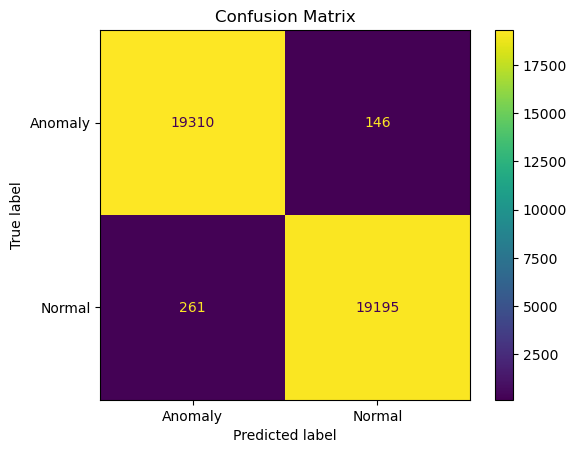

In [10]:

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
#Now that we have the best hyperparameters, we will do another prediction
y_pred_normal = best_model.predict(normal_test)
y_pred_anomaly = best_model.predict(anomaly_test)
y_pred = np.concatenate([y_pred_normal, y_pred_anomaly])
y_pred_binary = np.where(y_pred == 1, 1, 0)
y_true = np.concatenate([np.ones(len(normal_test)), np.zeros(len(anomaly_test))])

#Create a confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred_binary, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Anomaly', 'Normal'])
disp.plot()
plt.title("Confusion Matrix")
plt.show()


In [11]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
accuracy = accuracy_score(y_true, y_pred_binary)
precision = precision_score(y_true, y_pred_binary)
recall = recall_score(y_true, y_pred_binary)
f1 = f1_score(y_true, y_pred_binary)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


Accuracy:  0.9895
Precision: 0.9925
Recall:    0.9866
F1 Score:  0.9895


In [12]:
#Want to apply to the entire anomaly dataset now, since we know our best parameters now

Evaluate the fully anomaly dataset


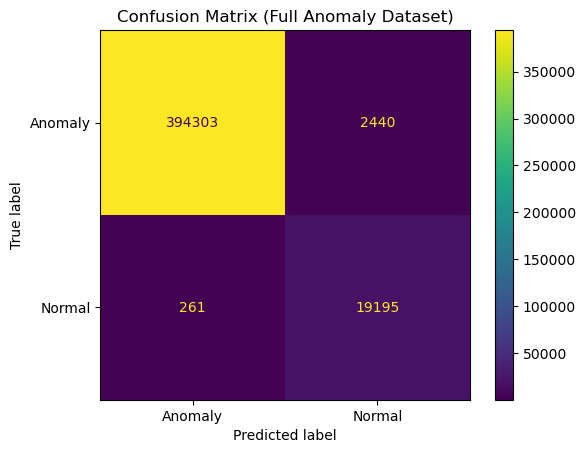

Accuracy:  0.9935
Precision: 0.8872
Recall:    0.9866
F1 Score:  0.9343


In [13]:
#Now we will evaluate the full anomaly dataset
print("Evaluate the fully anomaly dataset")

#Retraining 
full_clf = OneClassSVM(nu=best_params['nu'], kernel='rbf', gamma=best_params['gamma'])
full_clf.fit(normal_train)

#Predict on normal test data and all anomaly data
y_pred_normal = full_clf.predict(normal_test)
y_pred_full_anomaly = full_clf.predict(anomaly_data)  # Using all anomaly data

#Combine predictions
y_pred = np.concatenate([y_pred_normal, y_pred_full_anomaly])
y_pred_binary = np.where(y_pred == 1, 1, 0)

#Combine true labels (1 for normal, 0 for anomaly)
y_true = np.concatenate([np.ones(len(normal_test)), np.zeros(len(anomaly_data))])

#Create another confusion matrix
cm = confusion_matrix(y_true, y_pred_binary, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Anomaly', 'Normal'])
disp.plot()
plt.title("Confusion Matrix (Full Anomaly Dataset)")
plt.show()

accuracy = accuracy_score(y_true, y_pred_binary)
precision = precision_score(y_true, y_pred_binary)
recall = recall_score(y_true, y_pred_binary)
f1 = f1_score(y_true, y_pred_binary)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")


pandas: 2.2.3
numpy: 2.2.4
scikit-learn: 1.6.1
matplotlib: 3.10.0
